In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/micoplastic/microplastic_100.v4i.yolov8/README.dataset.txt
/kaggle/input/micoplastic/microplastic_100.v4i.yolov8/README.roboflow.txt
/kaggle/input/micoplastic/microplastic_100.v4i.yolov8/data.yaml
/kaggle/input/micoplastic/microplastic_100.v4i.yolov8/app.py
/kaggle/input/micoplastic/microplastic_100.v4i.yolov8/valid/labels/67_png.rf.3ff8e2d78b2267ddd4942c79ee080f2d.txt
/kaggle/input/micoplastic/microplastic_100.v4i.yolov8/valid/labels/29_png.rf.d12ebcf07583077f6853830a56ba649e.txt
/kaggle/input/micoplastic/microplastic_100.v4i.yolov8/valid/labels/40_png.rf.f621914519e439b936bebc9cece2cfd3.txt
/kaggle/input/micoplastic/microplastic_100.v4i.yolov8/valid/labels/148-b_png.rf.3d0f091593b5e22a2ae9796e968a799b.txt
/kaggle/input/micoplastic/microplastic_100.v4i.yolov8/valid/labels/9_png.rf.ad6ba551ff28ad563abb479595c7f817.txt
/kaggle/input/micoplastic/microplastic_100.v4i.yolov8/valid/labels/107_png.rf.cfb0e8f94d99e2096eb775a243f38c35.txt
/kaggle/input/micoplastic/microplastic_10

In [2]:
!pip install ultralytics --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 25.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 29.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.3 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 82.8 MB/s eta 0:00:00:00:0100:01


In [3]:
import os

dataset_path = "/kaggle/input/micoplastic/microplastic_100.v4i.yolov8"  # change if it's different

print("Contents of dataset folder:")
print(os.listdir(dataset_path))
print("\nTrain images:", len(os.listdir(os.path.join(dataset_path, "train/images"))))
print("Train labels:", len(os.listdir(os.path.join(dataset_path, "train/labels"))))
print("Valid images:", len(os.listdir(os.path.join(dataset_path, "valid/images"))))
print("Valid labels:", len(os.listdir(os.path.join(dataset_path, "valid/labels"))))
print("test labels:", len(os.listdir(os.path.join(dataset_path, "test/labels"))))
print("test labels:", len(os.listdir(os.path.join(dataset_path, "test/labels"))))


Contents of dataset folder:
['README.dataset.txt', 'README.roboflow.txt', 'data.yaml', 'app.py', 'valid', 'test', 'train']

Train images: 315
Train labels: 315
Valid images: 37
Valid labels: 37
test labels: 9
test labels: 9


In [75]:
import yaml

# Load the data.yaml file
with open('/kaggle/input/micoplastic/microplastic_100.v4i.yolov8/data.yaml', 'r') as file:
    data = yaml.safe_load(file)

# Print class names
print("Number of classes:", data['nc'])
print("Class names:", data['names'])


Number of classes: 4
Class names: ['fiber', 'film', 'fragment', 'pallet']


In [4]:
import os

# Path to your dataset
train_label_folder = '/kaggle/input/micoplastic/microplastic_100.v4i.yolov8/train/labels'

# List of class names from the data.yaml file
class_names = ['fiber', 'film', 'fragment', 'pallet']

# Initialize a dictionary to count occurrences of each class
label_counts = {class_name: 0 for class_name in class_names}

# Loop through each label file in the train folder
for label_file in os.listdir(train_label_folder):
    if label_file.endswith('.txt'):
        with open(os.path.join(train_label_folder, label_file), 'r') as file:
            labels = file.readlines()
            for label in labels:
                class_id = int(label.split()[0])  # First element is the class ID
                label_counts[class_names[class_id]] += 1

# Print out the label distribution
print("Label distribution (train set):")
for class_name, count in label_counts.items():
    print(f"{class_name}: {count}")


Label distribution (train set):
fiber: 816
film: 948
fragment: 912
pallet: 909


In [5]:
import os
import cv2
import matplotlib.pyplot as plt
import random
import numpy as np
from PIL import Image

# Dataset paths
image_path = '/kaggle/input/micoplastic/microplastic_100.v4i.yolov8/train/images'
label_path = '/kaggle/input/micoplastic/microplastic_100.v4i.yolov8/train/labels'
class_names = ['fiber', 'film', 'fragment', 'pellet']


In [6]:
import os
import cv2
import numpy as np
from PIL import Image
from tqdm import tqdm

def preprocess_image_color_clahe(image_pil):
    img = np.array(image_pil)
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    channels = cv2.split(img)
    clahe_channels = [clahe.apply(c) for c in channels]
    clahe_img = cv2.merge(clahe_channels)
    blurred = cv2.GaussianBlur(clahe_img, (5, 5), 0)
    return cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB)

# Base paths
input_base = "/kaggle/input/micoplastic/microplastic_100.v4i.yolov8"     # change this
output_base = "/kaggle/working/preprocessed_dataset"

splits = ['train', 'valid', 'test']

for split in splits:
    img_in_dir = os.path.join(input_base, split, "images")
    lbl_in_dir = os.path.join(input_base, split, "labels")

    img_out_dir = os.path.join(output_base, split, "images")
    lbl_out_dir = os.path.join(output_base, split, "labels")

    os.makedirs(img_out_dir, exist_ok=True)
    os.makedirs(lbl_out_dir, exist_ok=True)

    for fname in tqdm(os.listdir(img_in_dir), desc=f"Preprocessing {split}"):
        img_path = os.path.join(img_in_dir, fname)
        img_pil = Image.open(img_path).convert("RGB")
        processed = preprocess_image_color_clahe(img_pil)

        out_path = os.path.join(img_out_dir, fname)
        cv2.imwrite(out_path, cv2.cvtColor(processed, cv2.COLOR_RGB2BGR))

    # Copy labels (no changes)
    for lbl_file in os.listdir(lbl_in_dir):
        src = os.path.join(lbl_in_dir, lbl_file)
        dst = os.path.join(lbl_out_dir, lbl_file)
        os.system(f"cp '{src}' '{dst}'")


Preprocessing test: 100%|██████████| 9/9 [00:00<00:00, 64.01it/s]


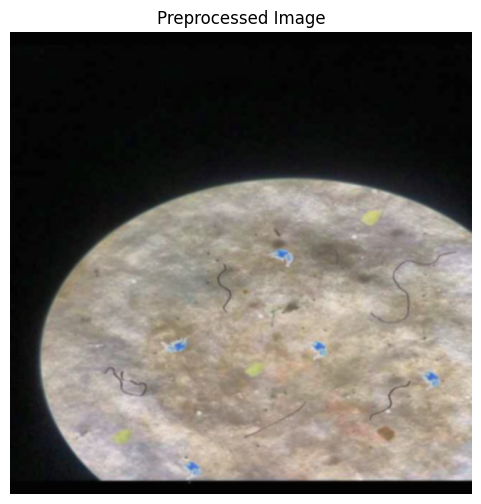

In [8]:
import cv2
import matplotlib.pyplot as plt

# Path to your preprocessed image
image_path = "/kaggle/working/preprocessed_dataset/valid/images/100_png.rf.36a5f581f4ce10b81cb7fb213f107e19.jpg"

# Load and convert the image from BGR (OpenCV) to RGB (matplotlib)
image = cv2.imread(image_path)
if image is None:
    print(f"Error: Image not found at {image_path}")
else:
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Display the image
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis('off')
    plt.title("Preprocessed Image")
    plt.show()


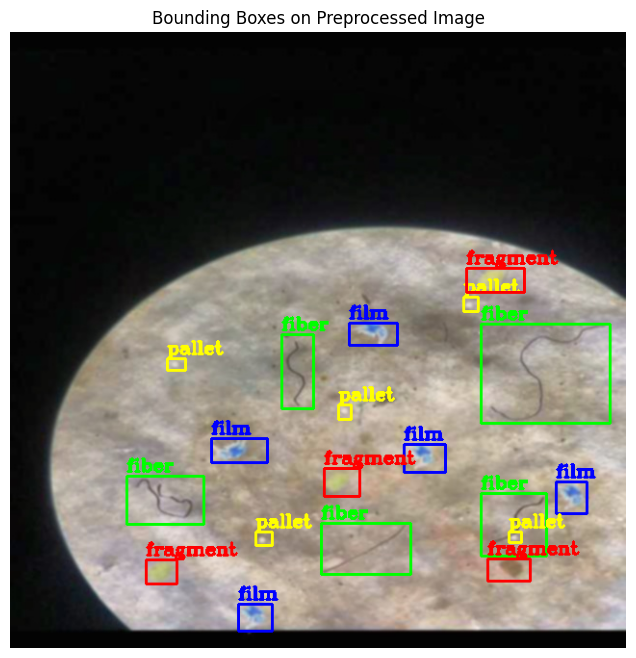

In [ ]:
import random

def draw_yolo_boxes(image_path, label_path, class_names):
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error: Image not found at {image_path}")
        return
    h, w, _ = image.shape

    if not os.path.exists(label_path):
        print(f"Error: Label file not found at {label_path}")
        return

    # Define unique colors for each class (you can customize this)
    colors = [
        (0, 255, 0),  # Green for fiber
        (255, 0, 0),  # Blue for film
        (0, 0, 255),  # Red for fragment
        (0, 255, 255) # Yellow for pallet
    ]
    
    with open(label_path, 'r') as f:
        for line in f.readlines():
            cls, x_center, y_center, box_w, box_h = map(float, line.strip().split())
            x1 = int((x_center - box_w / 2) * w)
            y1 = int((y_center - box_h / 2) * h)
            x2 = int((x_center + box_w / 2) * w)
            y2 = int((y_center + box_h / 2) * h)
            
            # Choose color for the class
            color = colors[int(cls)]

            # Draw the bounding box with class-specific color
            cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)
            
            # Draw the text with class-specific color
            cv2.putText(image, class_names[int(cls)], (x1, y1 - 5),
                        cv2.FONT_HERSHEY_COMPLEX, 0.6, color, 2)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.axis('off')
    plt.title("Bounding Boxes on Preprocessed Image")
    plt.show()

# Usage with your 4 classes
draw_yolo_boxes(
    image_path="/kaggle/working/preprocessed_dataset/test/images/100_png.rf.36a5f581f4ce10b81cb7fb213f107e19.jpg",
    label_path="/kaggle/working/preprocessed_dataset/test/labels/100_png.rf.36a5f581f4ce10b81cb7fb213f107e19.txt",
    class_names=['fiber', 'film', 'fragment', 'pallet']
)


In [11]:
image_files = [f.replace('.jpg', '.txt') for f in os.listdir('/kaggle/working/preprocessed_dataset/train/images')]
label_files = os.listdir('/kaggle/working/preprocessed_dataset/train/labels')

missing_labels = [f for f in image_files if f not in label_files]

print(f"Missing label files for {len(missing_labels)} images")
print(missing_labels[:5])  # show a few examples


Missing label files for 0 images
[]


In [12]:
!pip install ultralytics --quiet



In [13]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [120]:


# Load a pretrained model
model = YOLO('yolov8x.pt')  # Or you can use another version (like yolov8m.pt)

model.train(
    data='/kaggle/input/datayaml/Data.yaml',
    epochs=100,
    imgsz=640,
    batch=8,
    name='microplastic_yolov8x',
    augment=True,
    model='yolov8x.pt',
    optimizer='AdamW',  # supports weight decay
    weight_decay=0.0005,
    patience=20# lower decay = stronger regularization
)



New https://pypi.org/project/ultralytics/8.3.126 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.125 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: task=detect, mode=train, model=yolov8x.pt, data=/kaggle/input/datayaml/Data.yaml, epochs=100, time=None, patience=20, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=microplastic_yolov8x4, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=True, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=Fal

train: Scanning /kaggle/working/preprocessed_dataset/train/labels.cache... 315 images, 0 backgrounds, 0 corrupt: 100%|██████████| 315/315 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 513.6±395.2 MB/s, size: 64.8 KB)


val: Scanning /kaggle/working/preprocessed_dataset/valid/labels.cache... 37 images, 0 backgrounds, 0 corrupt: 100%|██████████| 37/37 [00:00<?, ?it/s]


...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:03<00:00,  1.20s/it]


                   all         37        453      0.894       0.94      0.917      0.464
                 fiber         37        112      0.992          1      0.995      0.675
                  film         37        115       0.97      0.974      0.962      0.443
              fragment         37        113      0.978      0.982      0.984      0.468
                pallet         37        113      0.637      0.805      0.727      0.271


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 0.2ms preprocess, 77.2ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to runs/detect/microplastic_yolov8x4


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a21587f70d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [121]:
import shutil
from IPython.display import FileLink

# Zip the output directory
shutil.make_archive('microplastic_yolov8x_output', 'zip', '/kaggle/working/runs/detect/microplastic_yolov8x4')

# Create download link
FileLink('microplastic_yolov8x_output.zip')


/kaggle/working/microplastic_yolov8x_output.zip


image 1/1 /kaggle/working/preprocessed_dataset/test/images/100_png.rf.9cc6749d84a327fc52c47b16e1818b5f.jpg: 640x640 5 fibers, 5 films, 4 fragments, 4 pallets, 37.9ms
Speed: 5.9ms preprocess, 37.9ms inference, 229.0ms postprocess per image at shape (1, 3, 640, 640)


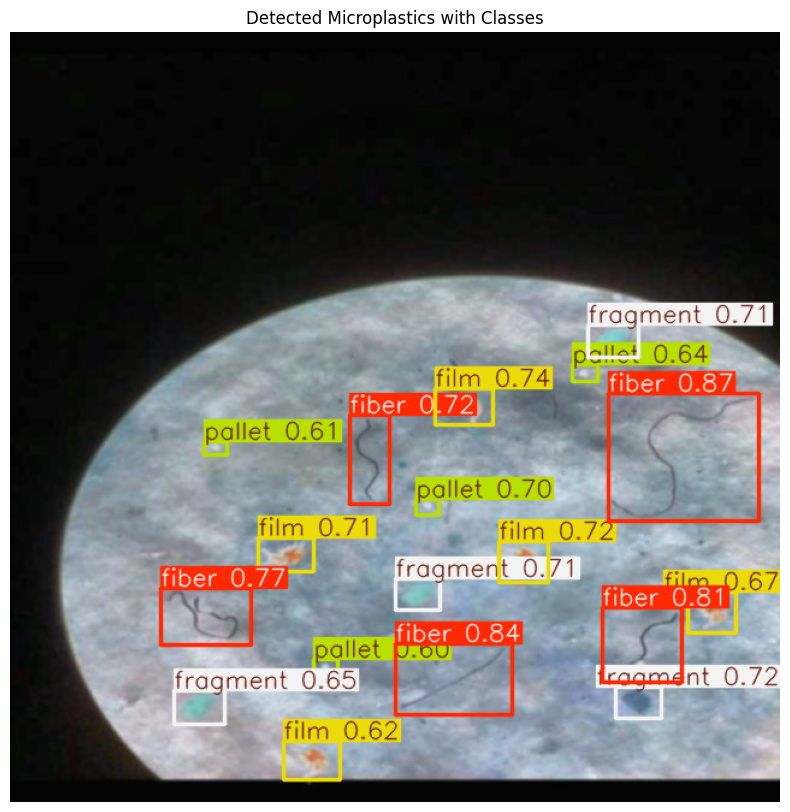

In [14]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import os

# Load your trained model
model = YOLO('/kaggle/input/bestptyolo/best.pt')  # Update this path as needed

# Define the class names
class_names = ['fiber', 'film', 'fragment', 'pellet']

# Path to a test image
image_dir = '/kaggle/working/preprocessed_dataset/test/images'
sample_image = os.listdir(image_dir)[0]  # you can change the index to test other images
image_path = os.path.join(image_dir, sample_image)

# Run prediction
results = model(image_path)

# Get image with bounding boxes drawn
img_pred = results[0].plot()

# Display the image with predictions
plt.figure(figsize=(10, 10))
plt.imshow(img_pred)
plt.axis('off')
plt.title("Detected Microplastics with Classes")
plt.show()


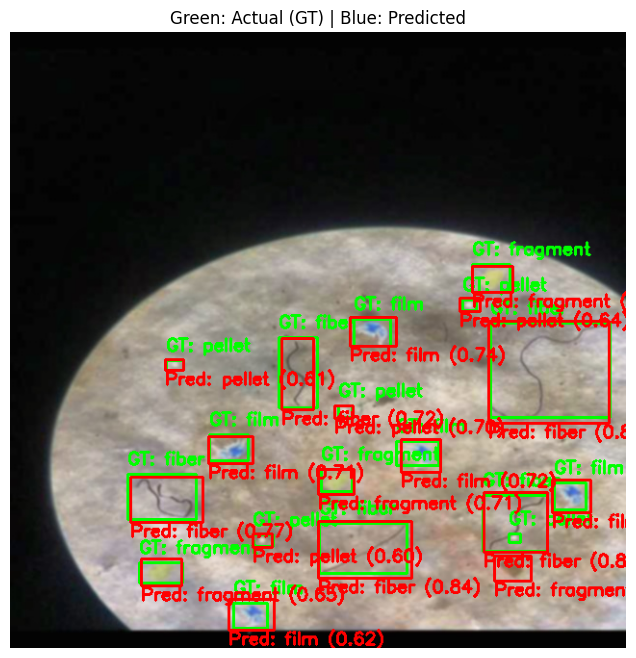

In [ ]:
import os
import cv2
import torch
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Paths - update these as needed
image_path = '/kaggle/working/preprocessed_dataset/test/images'
label_path = '/kaggle/working/preprocessed_dataset/test/labels'
model_path = '/kaggle/input/bestptyolo/best.pt'  # update if needed
class_names = ['fiber', 'film', 'fragment', 'pellet']

# Load model
model = YOLO(model_path)

# Pick one sample image
image_file = os.path.join(image_path, os.listdir(image_path)[0])
label_file = os.path.join(label_path, os.path.splitext(os.path.basename(image_file))[0] + '.txt')

# Load image
img = cv2.imread(image_file)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

# Draw ground truth boxes (green)
if os.path.exists(label_file):
    with open(label_file, 'r') as f:
        for line in f:
            cls_id, x_center, y_center, box_w, box_h = map(float, line.strip().split())
            x1 = int((x_center - box_w / 2) * w)
            y1 = int((y_center - box_h / 2) * h)
            x2 = int((x_center + box_w / 2) * w)
            y2 = int((y_center + box_h / 2) * h)
            cls_id = int(cls_id)
            cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(img_rgb, f"GT: {class_names[cls_id]}", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

# Run prediction
results = model(image_file, verbose=False)[0]

# Draw predicted boxes (blue)
for box in results.boxes:
    cls_id = int(box.cls.item())
    conf = float(box.conf.item())
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (255, 0, 0), 2)
    cv2.putText(img_rgb, f"Pred: {class_names[cls_id]} ({conf:.2f})", (x1, y2 + 15), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

# Show result
plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)
plt.axis('off')
plt.title("Green: Actual (GT) | Red: Predicted")
plt.show()


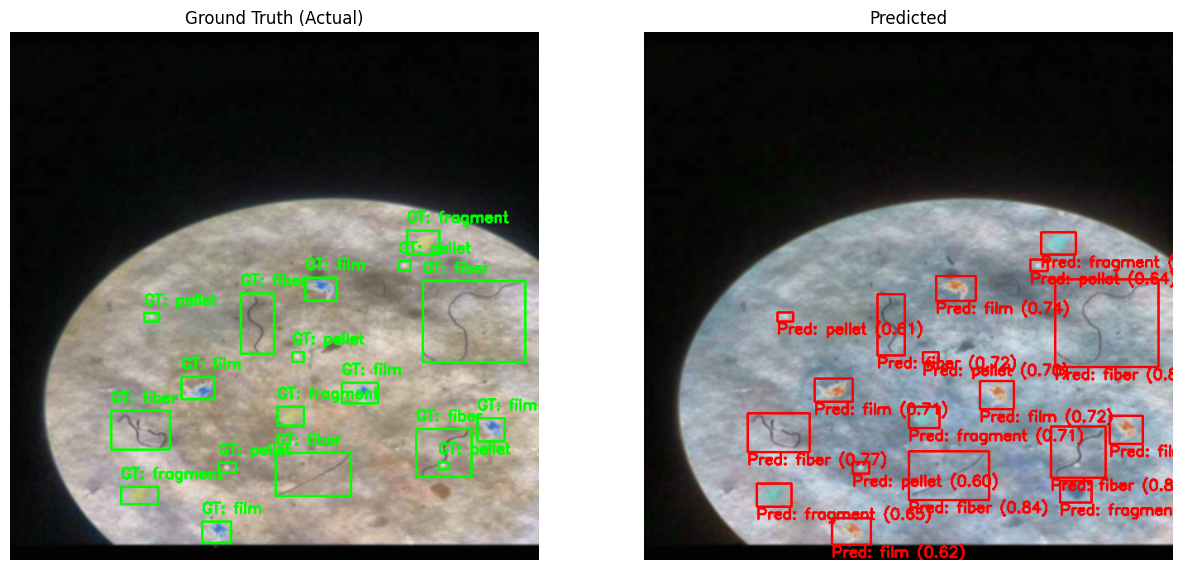

In [17]:
import os
import cv2
import torch
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Paths - update these as needed
image_path = '/kaggle/working/preprocessed_dataset/test/images'
label_path = '/kaggle/working/preprocessed_dataset/test/labels'
model_path = '/kaggle/input/bestptyolo/best.pt'  # update if needed
class_names = ['fiber', 'film', 'fragment', 'pellet']

# Load model
model = YOLO(model_path)

# Pick one sample image
image_file = os.path.join(image_path, os.listdir(image_path)[0])
label_file = os.path.join(label_path, os.path.splitext(os.path.basename(image_file))[0] + '.txt')

# Load image
img = cv2.imread(image_file)
img_rgb_gt = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # for ground truth
img_rgb_pred = img.copy()  # to store predictions (copy of original)

h, w = img.shape[:2]

# Draw ground truth boxes (green) on the left side image
if os.path.exists(label_file):
    with open(label_file, 'r') as f:
        for line in f:
            cls_id, x_center, y_center, box_w, box_h = map(float, line.strip().split())
            x1 = int((x_center - box_w / 2) * w)
            y1 = int((y_center - box_h / 2) * h)
            x2 = int((x_center + box_w / 2) * w)
            y2 = int((y_center + box_h / 2) * h)
            cls_id = int(cls_id)
            cv2.rectangle(img_rgb_gt, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(img_rgb_gt, f"GT: {class_names[cls_id]}", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

# Run prediction
results = model(image_file, verbose=False)[0]

# Draw predicted boxes (blue) on the right side image
for box in results.boxes:
    cls_id = int(box.cls.item())
    conf = float(box.conf.item())
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    cv2.rectangle(img_rgb_pred, (x1, y1), (x2, y2), (255, 0, 0), 2)
    cv2.putText(img_rgb_pred, f"Pred: {class_names[cls_id]} ({conf:.2f})", (x1, y2 + 15), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

# Plot side-by-side comparison (Actual vs Predicted)
plt.figure(figsize=(15, 8))

# Left side - Ground Truth
plt.subplot(1, 2, 1)
plt.imshow(img_rgb_gt)
plt.title("Ground Truth (Actual)")
plt.axis('off')

# Right side - Prediction
plt.subplot(1, 2, 2)
plt.imshow(img_rgb_pred)
plt.title("Predicted")
plt.axis('off')

plt.show()


Enter the path of the test image:  /kaggle/working/preprocessed_dataset/test/images/46_png.rf.14ce4c4e2f0842a83871a1ba425a11ba.jpg



image 1/1 /kaggle/working/preprocessed_dataset/test/images/46_png.rf.14ce4c4e2f0842a83871a1ba425a11ba.jpg: 640x640 5 fibers, 2 films, 2 fragments, 1 pallet, 37.5ms
Speed: 1.7ms preprocess, 37.5ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


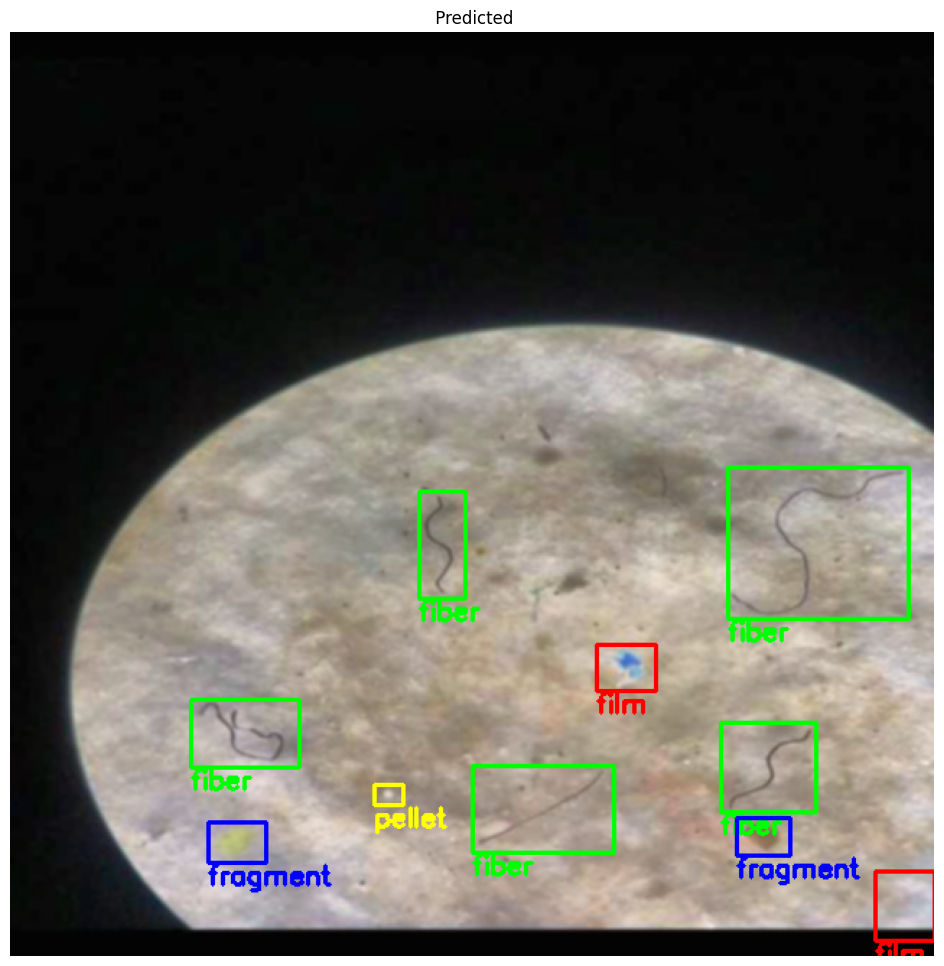

In [23]:
import os
import cv2
import torch
import matplotlib.pyplot as plt
from ultralytics import YOLO

# CONFIG: Set your class names
class_names = ['fiber', 'film', 'fragment', 'pellet']

# Define class colors for visualization (one unique color per class)
class_colors = {
    'fiber': (0, 255, 0),    # Green
    'film': (255, 0, 0),     # Red
    'fragment': (0, 0, 255), # Blue
    'pellet': (255, 255, 0)  # Yellow
}

# Load the YOLO model (adjust the path to your model)
model_path = '/kaggle/input/bestptyolo/best.pt'  # Update with your model path
model = YOLO(model_path)

# Function to draw boxes on an image (for ground truth and predictions)
def draw_boxes_on_image(img, label_file, results=None, class_names=class_names, class_colors=class_colors):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    # Draw ground truth boxes (green) if label file exists
    if os.path.exists(label_file):
        with open(label_file, 'r') as f:
            for line in f:
                cls_id, x_center, y_center, box_w, box_h = map(float, line.strip().split())
                x1 = int((x_center - box_w / 2) * w)
                y1 = int((y_center - box_h / 2) * h)
                x2 = int((x_center + box_w / 2) * w)
                y2 = int((y_center + box_h / 2) * h)
                cls_id = int(cls_id)
                color = class_colors[class_names[cls_id]]  # Assign color based on class
                cv2.rectangle(img_rgb, (x1, y1), (x2, y2), color, 2)
                cv2.putText(img_rgb, f"GT: {class_names[cls_id]}", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    # Draw predicted boxes (with class name) if results are passed
    if results:
        for box in results.boxes:
            cls_id = int(box.cls.item())
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            color = class_colors[class_names[cls_id]]  # Assign color based on class
            cv2.rectangle(img_rgb, (x1, y1), (x2, y2), color, 2)
            cv2.putText(img_rgb, f"{class_names[cls_id]}", (x1, y2 + 15), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    return img_rgb

# User Input for Test Image Path
image_path = input("Enter the path of the test image: ")
label_path = os.path.splitext(image_path)[0] + '.txt'  # Assuming labels have the same name as the image file

# Load the test image
img = cv2.imread(image_path)

# Perform object detection on the input image
results = model(image_path)[0]

# Draw ground truth and predicted boxes on the image
img_result = draw_boxes_on_image(img, label_path, results, class_names, class_colors)

# Plot the result
plt.figure(figsize=(12, 12))
plt.imshow(img_result)
plt.title(" Predicted")
plt.axis('off')
plt.show()


In [128]:
import shutil

# Path to your preprocessed dataset folder
dataset_folder = "/kaggle/working/preprocessed_dataset"

# Create a zip file
shutil.make_archive("/kaggle/working/preprocessed_dataset", 'zip', dataset_folder)


'/kaggle/working/preprocessed_dataset.zip'

In [24]:
from ultralytics import YOLO

model = YOLO("/kaggle/input/bestptyolo/best.pt")  # Adjust if needed

results = model.val(
    data="/kaggle/input/datayaml/Data.yaml",
    split="test",
    save_json=True,
    save_txt=True
)

# Top-level metric values (YOLOv8)
print(f"Precision (mean):   {results.box.mp:.4f}")
print(f"Recall (mean):      {results.box.mr:.4f}")
print(f"mAP@0.5:            {results.box.map50:.4f}")

Ultralytics 8.3.137 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 112 layers, 68,127,420 parameters, 0 gradients, 257.4 GFLOPs


100%|██████████| 755k/755k [00:00<00:00, 28.3MB/s]

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1520.3±470.0 MB/s, size: 64.8 KB)



val: Scanning /kaggle/working/preprocessed_dataset/test/labels... 9 images, 0 backgrounds, 0 corrupt: 100%|██████████| 9/9 [00:00<00:00, 1261.44it/s]

val: New cache created: /kaggle/working/preprocessed_dataset/test/labels.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:01<00:00,  1.98s/it]


                   all          9         98      0.926      0.942      0.918      0.487
                 fiber          9         20      0.977          1      0.995      0.728
                  film          9         25      0.982          1      0.995       0.49
              fragment          9         28      0.874      0.929      0.873      0.475
                pallet          9         25       0.87       0.84      0.807      0.253


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 0.2ms preprocess, 34.6ms inference, 0.0ms loss, 0.9ms postprocess per image
Saving runs/detect/val/predictions.json...
Results saved to runs/detect/val
Precision (mean):   0.9259
Recall (mean):      0.9421
mAP@0.5:            0.9175
